### 1. Preparação dos Dados
Vamos listar os caminhos das imagens e rótulos. O OpenEDS geralmente separa os dados em subpastas (S_0, S_1, etc.).

# Segmentação de Olhos — OpenEDS + U-Net
**Pipeline:**
1. Carrega imagens `.png` e máscaras `.npy` do dataset OpenEDS (`S_*`)
2. Treina uma U-Net para segmentar 4 classes: Fundo (0), Íris (1), Pupila (2), Esclera (3)
3. Aplica o modelo treinado nas imagens Base64 do CSV `dados_olhos (2).csv`

## 0. Instalação de dependências

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch', 'torchvision', 'Pillow', 'numpy', 'pandas', 'matplotlib', 'tqdm'], check=True)
print('Dependências OK')

Dependências OK


## 1. Imports e configurações

In [ ]:
import os
import glob
import base64
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from PIL import Image, ImageOps
from tqdm import tqdm

In [ ]:

# ──── CONFIGURAÇÕES ────────────────────────────────────────────────────────────
BASE_DIR  = '/workspaces/coding/openEDS'   # pasta com S_0, S_1, ...
CSV_PATH  = '/workspaces/coding/dados_olhos (2).csv'
MODEL_PATH = '/workspaces/coding/unet_eye.pth'

IMG_SIZE   = (256, 256)   # resize para treino/inferência
N_CLASSES  = 4            # 0=fundo, 1=íris, 2=pupila, 3=esclera
BATCH_SIZE = 8
N_EPOCHS   = 10            # aumente para melhor desempenho
LR         = 1e-3
MAX_BATCHES_PER_EPOCH = 100  # None = usa tudo; coloque ex: 200 para teste rápido

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

CLASS_NAMES  = ['Fundo', 'Íris', 'Pupila', 'Esclera']
CLASS_COLORS = ['black', 'royalblue', 'gold', 'lightcoral']

Dispositivo: cuda


## 2. Dataset OpenEDS
Cada subpasta `S_*` contém:
- `N.png`  → imagem em escala de cinza (400×640)
- `N.npy`  → máscara de segmentação com valores 0-3 (400×640)

O Dataset emparelha cada `.png` com o `.npy` de mesmo nome.

In [3]:
class OpenEDSDataset(Dataset):
    """Dataset que emparelha PNG (imagem) com NPY (máscara) do OpenEDS."""

    def __init__(self, base_path, img_size=(256, 256)):
        self.img_size = img_size
        png_files = sorted(glob.glob(os.path.join(base_path, 'S_*', '*.png')))
        self.pairs = []
        for png in png_files:
            npy = os.path.splitext(png)[0] + '.npy'
            if os.path.exists(npy):
                self.pairs.append((png, npy))
        print(f'Pares imagem+máscara encontrados: {len(self.pairs)}')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        png_path, npy_path = self.pairs[idx]

        # Imagem em escala de cinza → tensor [1, H, W] float
        image = Image.open(png_path).convert('L')
        image = image.resize(self.img_size, Image.BILINEAR)
        image = TF.to_tensor(image)  # [1, H, W], valores 0-1

        # Máscara inteira → tensor [H, W] long
        mask = np.load(npy_path).astype(np.int64)
        mask = Image.fromarray(mask.astype(np.uint8))
        mask = mask.resize(self.img_size, Image.NEAREST)
        mask = torch.from_numpy(np.array(mask)).long()

        return image, mask


dataset = OpenEDSDataset(BASE_DIR, img_size=IMG_SIZE)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

Pares imagem+máscara encontrados: 27431


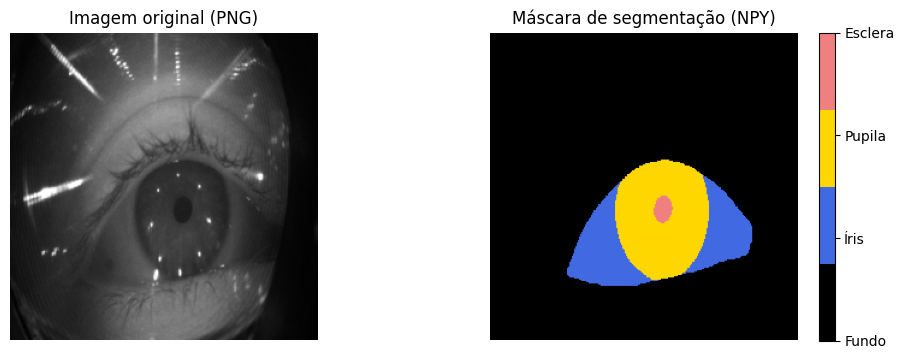

In [32]:
# Visualizar uma amostra
cmap = mcolors.ListedColormap(CLASS_COLORS)
img_sample, mask_sample = dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_sample.squeeze(), cmap='gray')
axes[0].set_title('Imagem original (PNG)')
axes[0].axis('off')
im = axes[1].imshow(mask_sample.numpy(), cmap=cmap, vmin=0, vmax=3)
axes[1].set_title('Máscara de segmentação (NPY)')
axes[1].axis('off')
cbar = fig.colorbar(im, ax=axes[1], ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(CLASS_NAMES)
plt.show()

## 3. Modelo — U-Net

In [4]:
def double_conv(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c,  out_c, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
    )


class UNet(nn.Module):
    """U-Net com encoder/decoder de 4 níveis para segmentação 1-canal → N classes."""

    def __init__(self, in_channels=1, n_classes=4, base_f=32):
        super().__init__()
        f = base_f
        # Encoder
        self.enc1 = double_conv(in_channels, f)
        self.enc2 = double_conv(f,   f*2)
        self.enc3 = double_conv(f*2, f*4)
        self.enc4 = double_conv(f*4, f*8)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = double_conv(f*8, f*16)
        # Decoder
        self.up4   = nn.ConvTranspose2d(f*16, f*8,  kernel_size=2, stride=2)
        self.dec4  = double_conv(f*16, f*8)
        self.up3   = nn.ConvTranspose2d(f*8,  f*4,  kernel_size=2, stride=2)
        self.dec3  = double_conv(f*8,  f*4)
        self.up2   = nn.ConvTranspose2d(f*4,  f*2,  kernel_size=2, stride=2)
        self.dec2  = double_conv(f*4,  f*2)
        self.up1   = nn.ConvTranspose2d(f*2,  f,    kernel_size=2, stride=2)
        self.dec1  = double_conv(f*2,  f)
        self.out   = nn.Conv2d(f, n_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


model = UNet(in_channels=1, n_classes=N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net inicializada — parâmetros treináveis: {total_params:,}')

U-Net inicializada — parâmetros treináveis: 7,762,564


## 4. Treinamento

In [34]:
optimizer = Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history = []

print(f'Treinando por {N_EPOCHS} épocas no dispositivo: {DEVICE}')
print('=' * 55)

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    pbar = tqdm(loader, desc=f'Época {epoch}/{N_EPOCHS}', leave=False)
    for batch_idx, (imgs, masks) in enumerate(pbar):
        if MAX_BATCHES_PER_EPOCH and batch_idx >= MAX_BATCHES_PER_EPOCH:
            break

        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)          # [B, C, H, W]
        loss    = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = outputs.argmax(dim=1)
        correct += (preds == masks).sum().item()
        total   += masks.numel()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    scheduler.step()
    avg_loss = running_loss / (batch_idx + 1)
    acc      = 100.0 * correct / total
    history.append({'epoch': epoch, 'loss': avg_loss, 'acc': acc})
    print(f'Época {epoch:02d} | Loss: {avg_loss:.4f} | Pixel Acc: {acc:.2f}%')

print('=' * 55)
print('Treinamento concluído!')

# Salvar pesos
torch.save(model.state_dict(), MODEL_PATH)
print(f'Modelo salvo em: {MODEL_PATH}')

Treinando por 10 épocas no dispositivo: cuda


Época 01 | Loss: 0.0364 | Pixel Acc: 99.03%


Época 02 | Loss: 0.0097 | Pixel Acc: 99.61%


Época 03 | Loss: 0.0081 | Pixel Acc: 99.67%


Época 04 | Loss: 0.0068 | Pixel Acc: 99.72%


...

Época 06 | Loss: 0.0054 | Pixel Acc: 99.77%


Época 07 | Loss: 0.0050 | Pixel Acc: 99.79%


Época 08 | Loss: 0.0046 | Pixel Acc: 99.81%


Época 09 | Loss: 0.0043 | Pixel Acc: 99.82%


Época 10 | Loss: 0.0041 | Pixel Acc: 99.82%
Treinamento concluído!
Modelo salvo em: /workspaces/coding/unet_eye.pth


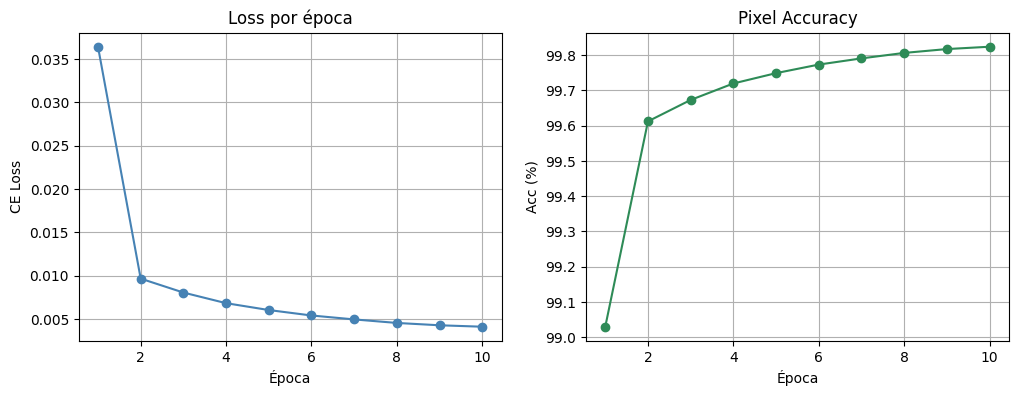

In [35]:
# Gráfico de treinamento
hist_df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_df['epoch'], hist_df['loss'], 'o-', color='steelblue')
ax1.set_title('Loss por época'); ax1.set_xlabel('Época'); ax1.set_ylabel('CE Loss'); ax1.grid(True)
ax2.plot(hist_df['epoch'], hist_df['acc'],  'o-', color='seagreen')
ax2.set_title('Pixel Accuracy'); ax2.set_xlabel('Época'); ax2.set_ylabel('Acc (%)'); ax2.grid(True)
plt.show()

## 5. Avaliação qualitativa no conjunto de treino

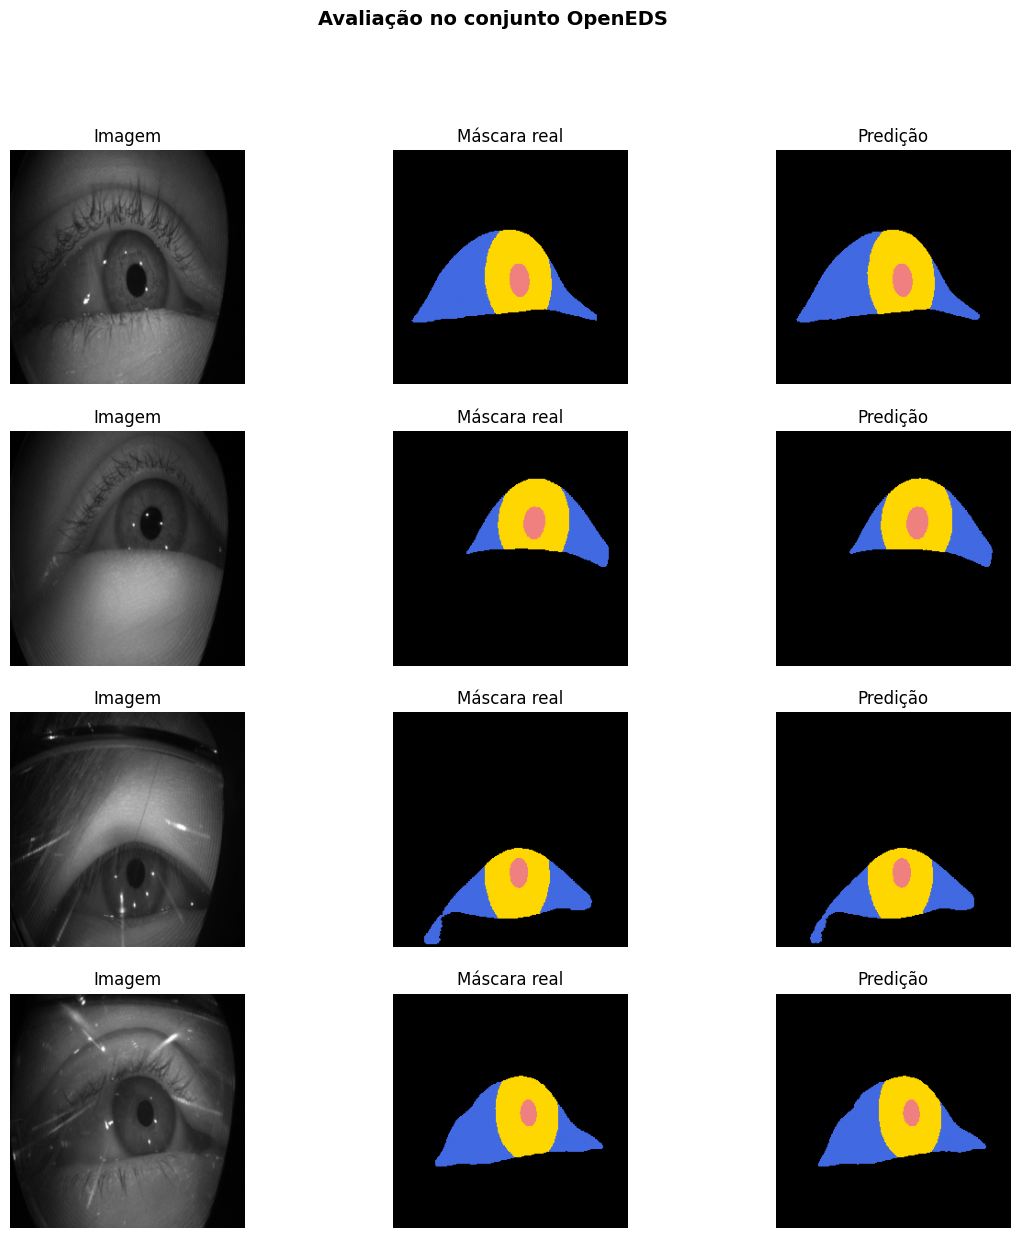

In [36]:
model.eval()
cmap = mcolors.ListedColormap(CLASS_COLORS)

n_show = 4
indices = np.random.choice(len(dataset), n_show, replace=False)

fig, axes = plt.subplots(n_show, 3, figsize=(14, n_show * 3.5))
fig.suptitle('Avaliação no conjunto OpenEDS', fontsize=14, fontweight='bold')

for row, idx in enumerate(indices):
    img, mask_gt = dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(DEVICE)).argmax(1).squeeze(0).cpu().numpy()

    axes[row, 0].imshow(img.squeeze(), cmap='gray')
    axes[row, 0].set_title('Imagem'); axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_gt.numpy(), cmap=cmap, vmin=0, vmax=3)
    axes[row, 1].set_title('Máscara real'); axes[row, 1].axis('off')

    axes[row, 2].imshow(pred, cmap=cmap, vmin=0, vmax=3)
    axes[row, 2].set_title('Predição'); axes[row, 2].axis('off')

plt.show()

## 6. Carregando o CSV e aplicando a segmentação
As imagens estão codificadas em **Base64** na coluna `IMAG`.

In [13]:
df_olhos = pd.read_csv(CSV_PATH)
print(f'CSV carregado: {len(df_olhos)} linhas')
print(df_olhos[['data_id', 'sensor_name', 'eye_side', 'tempo']].head())

CSV carregado: 376 linhas
   data_id sensor_name  eye_side  tempo
0        1      Triple  esquerdo    138
1        2      Triple  esquerdo    180
2        3      Triple  esquerdo    647
3        4      Triple  esquerdo   1102
4        5      Triple  esquerdo   1540


In [14]:
# Carregar modelo treinado de disco
model = UNet(in_channels=1, n_classes=N_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Modelo carregado de:", MODEL_PATH)

Modelo carregado de: /workspaces/coding/unet_eye.pth


In [16]:
def decode_base64_image(b64_str):
    """
    Decodifica Base64 (com ou sem prefixo data:image) em PIL Image grayscale.
    Usa conversão numpy manual para evitar que PIL acione cv2.cvtColor.
    """
    if ',' in b64_str:
        b64_str = b64_str.split(',', 1)[1]
    b64_str += '=' * (-len(b64_str) % 4)
    img_bytes = base64.b64decode(b64_str)
    pil_img = Image.open(io.BytesIO(img_bytes))
    arr = np.array(pil_img)          # numpy array — nunca chama cv2
    
    if arr.ndim == 3:
        # Luminância BT.601 — equivalente ao 'L' do PIL
        gray = (0.299  * arr[..., 0].astype(np.float32)
               + 0.587 * arr[..., 1].astype(np.float32)
               + 0.114 * arr[..., 2].astype(np.float32)).astype(np.uint8)
    elif arr.ndim == 2:
        gray = arr.astype(np.uint8)
    else:
        gray = arr.squeeze().astype(np.uint8)

    pil_img_rot = pil_img.transpose(Image.ROTATE_180)
    
    # 3. Equalização de Histograma Global (Alternativa ao CLAHE suportada pelo PIL)
    # Isso expandirá o histograma da imagem para melhorar o contraste geral
    pil_img_eq = ImageOps.equalize(pil_img_rot)
    
    # return Image.fromarray(gray, mode='L')
    return pil_img_eq

def segment_image(pil_img, model, device, img_size=(256, 256)):
    """Aplica o modelo U-Net a uma PIL Image e retorna a máscara predita."""
    img_resized = pil_img.resize(img_size, Image.BILINEAR)
    img_resized = img_resized.convert('L')
    tensor = TF.to_tensor(img_resized).unsqueeze(0).to(device)  # [1,1,H,W]
    model.eval()
    with torch.no_grad():
        pred = model(tensor).argmax(dim=1).squeeze(0).cpu().numpy()
    return pred


# Aplicar em todas as imagens do CSV
print(f'Aplicando segmentação em {len(df_olhos)} imagens...')
segmentacoes = []
imagens_orig = []

for idx, row in tqdm(df_olhos.iterrows(), total=len(df_olhos)):
    try:
        pil_img = decode_base64_image(row['IMAG'])
        mask    = segment_image(pil_img, model, DEVICE, IMG_SIZE)
        segmentacoes.append(mask)
        imagens_orig.append(pil_img)
    except Exception as e:
        print(f'Erro na linha {idx}: {e}')
        segmentacoes.append(None)
        imagens_orig.append(None)

print('Segmentação concluída!')

Aplicando segmentação em 376 imagens...


100%|██████████| 376/376 [00:10<00:00, 34.88it/s]

Segmentação concluída!


## 7. Visualização dos resultados no CSV

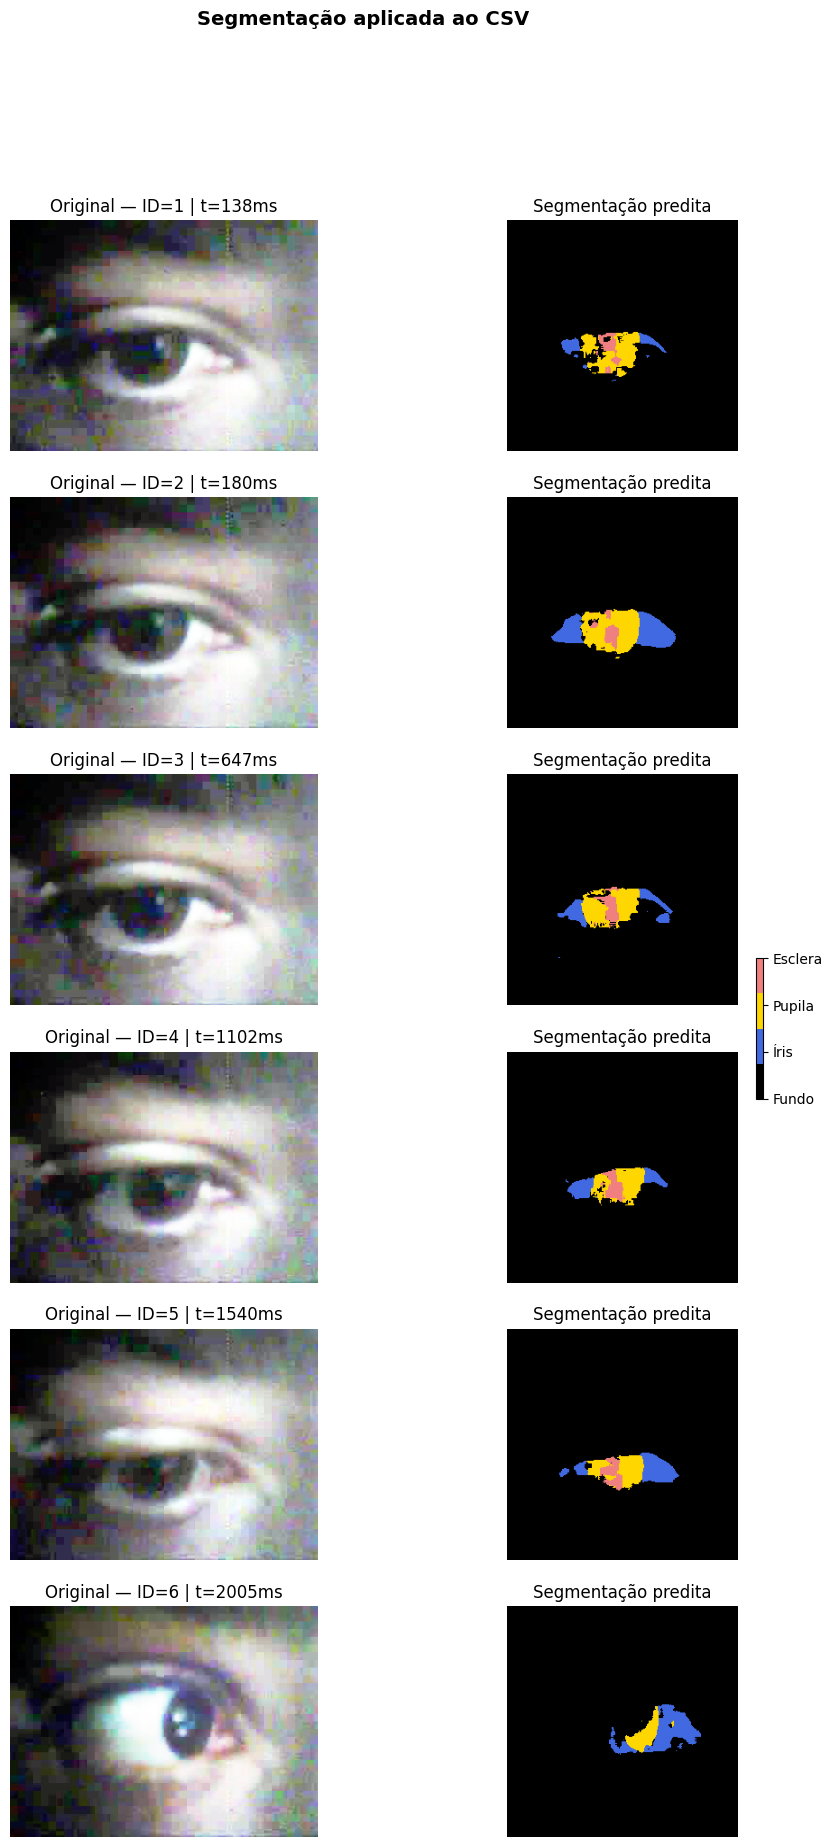

In [17]:
cmap = mcolors.ListedColormap(CLASS_COLORS)
n_show = min(6, len(df_olhos))

fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 3.5))
fig.suptitle('Segmentação aplicada ao CSV', fontsize=14, fontweight='bold')

for i in range(n_show):
    pil_img = imagens_orig[i]
    mask    = segmentacoes[i]
    info    = f"ID={df_olhos.iloc[i]['data_id']} | t={df_olhos.iloc[i]['tempo']}ms"

    axes[i, 0].imshow(pil_img, cmap='gray')
    axes[i, 0].set_title(f'Original — {info}'); axes[i, 0].axis('off')

    im = axes[i, 1].imshow(mask, cmap=cmap, vmin=0, vmax=3)
    axes[i, 1].set_title('Segmentação predita'); axes[i, 1].axis('off')

cbar = fig.colorbar(im, ax=axes[:, 1], ticks=[0, 1, 2, 3], fraction=0.02)
cbar.ax.set_yticklabels(CLASS_NAMES)
plt.show()

## 8. Estatísticas por imagem do CSV

In [ ]:
# Calcular área percentual de cada classe por imagem
stats = []
for i, (row_idx, row) in enumerate(df_olhos.iterrows()):
    mask = segmentacoes[i]
    if mask is None:
        continue
    total_pixels = mask.size
    entry = {
        'data_id':     row['data_id'],
        'sensor_name': row['sensor_name'],
        'eye_side':    row['eye_side'],
        'tempo_ms':    row['tempo'],
    }
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        pct = 100.0 * (mask == cls_id).sum() / total_pixels
        entry[f'pct_{cls_name.lower().replace("í","i")}'] = round(pct, 2)
    stats.append(entry)

df_stats = pd.DataFrame(stats)
print('Estatísticas de segmentação por imagem:')
display(df_stats.head(10))

In [ ]:
# Salvar estatísticas em CSV
out_csv = '/workspaces/coding/resultados_segmentacao.csv'
df_stats.to_csv(out_csv, index=False)
print(f'Resultados salvos em: {out_csv}')